# 03 Baseline Model

Objective: train a Linear Regression baseline model to predict `ClosePrice`.

This notebook uses the cleaned data and fixed-window rolling-origin split plan from `02_preprocessing.ipynb`:
- keep one fixed 5-month training window
- evaluate that fixed setup across five historical cutoffs spread across the available data period
- fit preprocessing and outlier thresholds inside each training cutoff only
- evaluate the final baseline once on the latest test month

Experiment design:
- historical stability cutoffs: `2025-09`, `2025-11`, `2026-01`, `2026-03`, `2026-04`
- final train: `2025-12` through `2026-04`
- final test: `2026-05`
- metrics: R², MAE, RMSE, MAPE, MdAPE


## 0. Setup


In [54]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
SPLIT_DIR = PROCESSED_DATA_DIR / "splits"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "week4_baseline"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CLEANED_CSV = PROCESSED_DATA_DIR / "crmls_week3_cleaned.csv"
SPLIT_PLAN_CSV = PROCESSED_DATA_DIR / "crmls_week3_split_plan.csv"
FINAL_TRAIN_CSV = SPLIT_DIR / "final_train_fixed_window_cleaned.csv"
TEST_CSV = SPLIT_DIR / "test_latest_month_cleaned.csv"
MODEL_PATH = MODEL_DIR / "linear_regression_baseline_pipeline.joblib"

print(f"Cleaned data: {CLEANED_CSV}")
print(f"Split directory: {SPLIT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Model path: {MODEL_PATH}")


Cleaned data: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/data/processed/crmls_week3_cleaned.csv
Split directory: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/data/processed/splits
Output directory: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week4_baseline
Model path: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/models/linear_regression_baseline_pipeline.joblib


## 1. Load Preprocessed Data and Split Plan


In [55]:
clean_df = pd.read_csv(CLEANED_CSV, low_memory=False)
split_plan = pd.read_csv(SPLIT_PLAN_CSV, dtype={"split_type": "string", "eval_month": "string"})

if "CloseDate" in clean_df.columns:
    clean_df["CloseDate"] = pd.to_datetime(clean_df["CloseDate"], errors="coerce")
if "close_month" in clean_df.columns:
    clean_df["close_month"] = pd.PeriodIndex(clean_df["close_month"], freq="M")

required_split_types = {"historical_eval", "final_test"}
assert required_split_types.issubset(set(split_plan["split_type"])), "Split plan is missing required split types."
assert clean_df["ClosePrice"].notna().all(), "ClosePrice should not contain missing values."
assert (clean_df["ClosePrice"] > 0).all(), "ClosePrice should be positive after preprocessing."

historical_plan = (
    split_plan[split_plan["split_type"] == "historical_eval"]
    .copy()
    .sort_values("eval_month")
)
final_plan = split_plan[split_plan["split_type"] == "final_test"].copy().iloc[0]

fixed_train_window_months = int(split_plan["train_window_months"].iloc[0])
historical_eval_months = historical_plan["eval_month"].astype(str).tolist()

display(split_plan)
print(f"Cleaned data shape: {clean_df.shape}")
print(f"Fixed training window: {fixed_train_window_months} months")
print(f"Historical stability cutoffs: {historical_eval_months}")


,split_type,train_window_months,train_month_start,train_month_end,train_months,eval_month,train_rows,eval_rows
0,historical_eval,5,2025-04,2025-08,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08",2025-09,58878,11449
1,historical_eval,5,2025-06,2025-10,"2025-06, 2025-07, 2025-08, 2025-09, 2025-10",2025-11,58713,9720
2,historical_eval,5,2025-08,2025-12,"2025-08, 2025-09, 2025-10, 2025-11, 2025-12",2026-01,55077,7485
3,historical_eval,5,2025-10,2026-02,"2025-10, 2025-11, 2025-12, 2026-01, 2026-02",2026-03,48213,11169
4,historical_eval,5,2025-11,2026-03,"2025-11, 2025-12, 2026-01, 2026-02, 2026-03",2026-04,47362,12025
5,final_test,5,2025-12,2026-04,"2025-12, 2026-01, 2026-02, 2026-03, 2026-04",2026-05,49667,12024


Cleaned data shape: (153758, 46)
Fixed training window: 5 months
Historical stability cutoffs: ['2025-09', '2025-11', '2026-01', '2026-03', '2026-04']


## 2. Define Model Features

These feature groups mirror `02_preprocessing.ipynb`. Leakage fields such as IDs, close date, source file, ListPrice-family fields, and post-close fields are excluded from model inputs.


In [56]:
target = "ClosePrice"
metadata_cols = ["ListingKey", "CloseDate", "close_month", "source_file"]

continuous_numeric_cols = [
    "LivingArea",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "AssociationFee",
]
count_numeric_cols = [
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "GarageSpaces",
    "ParkingTotal",
    "Stories",
]
numeric_cols = continuous_numeric_cols + count_numeric_cols
boolean_cols = ["ViewYN", "PoolPrivateYN", "AttachedGarageYN", "FireplaceYN", "NewConstructionYN"]
categorical_cols = ["City", "CountyOrParish", "PostalCode", "MLSAreaMajor", "Levels", "Flooring", "HighSchoolDistrict"]
flag_cols = [col for col in clean_df.columns if col.endswith("_missing") or col == "invalid_coordinates_flag"]

numeric_cols = [col for col in numeric_cols if col in clean_df.columns]
boolean_cols = [col for col in boolean_cols if col in clean_df.columns]
categorical_cols = [col for col in categorical_cols if col in clean_df.columns]
flag_cols = [col for col in flag_cols if col in clean_df.columns]
feature_cols = numeric_cols + categorical_cols + boolean_cols + flag_cols

feature_summary = pd.DataFrame({
    "feature_group": ["numeric", "categorical", "boolean", "missing_or_quality_flags", "total_raw_model_features"],
    "n_features": [len(numeric_cols), len(categorical_cols), len(boolean_cols), len(flag_cols), len(feature_cols)],
})
display(feature_summary)


,feature_group,n_features
0,numeric,11
1,categorical,7
2,boolean,5
3,missing_or_quality_flags,17
4,total_raw_model_features,40


## 3. Build Preprocessing and Model Pipeline

Every cutoff fits its own preprocessing pipeline on training data only. The one-hot output is kept sparse to avoid unnecessary memory use with high-cardinality location fields.


In [57]:
def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def build_preprocessing_pipeline(numeric_features, categorical_features, boolean_features, flag_features):
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
        ("onehot", make_onehot_encoder()),
    ])
    boolean_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent"))])
    flag_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="constant", fill_value=0))])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
            ("bool", boolean_pipeline, boolean_features),
            ("flag", flag_pipeline, flag_features),
        ],
        remainder="drop",
        sparse_threshold=0.3,
        verbose_feature_names_out=True,
    )


def build_baseline_model():
    return Pipeline(steps=[
        ("preprocess", build_preprocessing_pipeline(numeric_cols, categorical_cols, boolean_cols, flag_cols)),
        ("model", LinearRegression()),
    ])


## 4. Define Outlier and Evaluation Functions

ClosePrice outlier bounds are learned from the training data only using the 0.5th and 99.5th percentiles, then applied unchanged to the evaluation or test month.


In [58]:
def load_split_file(path):
    df = pd.read_csv(path, low_memory=False)
    if "CloseDate" in df.columns:
        df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
    if "close_month" in df.columns:
        df["close_month"] = pd.PeriodIndex(df["close_month"], freq="M")
    return df


def apply_train_price_bounds(train_df, eval_df, target_col="ClosePrice", lower_q=0.005, upper_q=0.995):
    lower_bound = train_df[target_col].quantile(lower_q)
    upper_bound = train_df[target_col].quantile(upper_q)
    train_mask = train_df[target_col].between(lower_bound, upper_bound)
    eval_mask = eval_df[target_col].between(lower_bound, upper_bound)
    return (
        train_df.loc[train_mask].copy(),
        eval_df.loc[eval_mask].copy(),
        {
            "price_lower_bound": lower_bound,
            "price_upper_bound": upper_bound,
            "train_rows_before_outlier_filter": len(train_df),
            "train_rows_after_outlier_filter": int(train_mask.sum()),
            "eval_rows_before_outlier_filter": len(eval_df),
            "eval_rows_after_outlier_filter": int(eval_mask.sum()),
        },
    )


def regression_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    absolute_percentage_error = ((y_true - y_pred).abs() / y_true).replace([np.inf, -np.inf], np.nan) * 100
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": absolute_percentage_error.mean(),
        "mdape": absolute_percentage_error.median(),
    }


## 5. Fixed-Window Rolling-Origin Backtest

Use the same 5-month training window at each historical cutoff. This is a stability check for the existing baseline design, not a training-window selection experiment. The cutoffs are intentionally spread across the historical data rather than limited to adjacent recent months.


In [59]:
def rolling_train_path(eval_month):
    return SPLIT_DIR / f"rolling_train_eval_{eval_month}_cleaned.csv"


def rolling_eval_path(eval_month):
    return SPLIT_DIR / f"rolling_eval_{eval_month}_cleaned.csv"


def run_historical_fold(plan_row):
    eval_month = str(plan_row["eval_month"])
    train_df_raw = load_split_file(rolling_train_path(eval_month))
    eval_df_raw = load_split_file(rolling_eval_path(eval_month))
    train_df, eval_df, bound_info = apply_train_price_bounds(train_df_raw, eval_df_raw)

    pipeline = build_baseline_model()
    pipeline.fit(train_df[feature_cols], train_df[target])
    predictions = pipeline.predict(eval_df[feature_cols])

    return {
        "train_window_months": int(plan_row["train_window_months"]),
        "eval_month": eval_month,
        "train_month_start": plan_row["train_month_start"],
        "train_month_end": plan_row["train_month_end"],
        "train_months": plan_row["train_months"],
        **bound_info,
        **regression_metrics(eval_df[target], predictions),
    }


stability_results = pd.DataFrame(
    run_historical_fold(plan_row)
    for _, plan_row in historical_plan.iterrows()
).sort_values("eval_month")

stability_results.to_csv(OUTPUT_DIR / "rolling_origin_results.csv", index=False)
display(stability_results.round(4))


,train_window_months,eval_month,train_month_start,train_month_end,train_months,price_lower_bound,price_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,r2,mae,rmse,mape,mdape
0,5,2025-09,2025-04,2025-08,"2025-04, 2025-05, 2025-06, 2025-07, 2025-08",190000.0,8500000.000,58878,58292,11449,11352,0.8202,229649.7565,393468.7650,22.8050,15.6521
1,5,2025-11,2025-06,2025-10,"2025-06, 2025-07, 2025-08, 2025-09, 2025-10",190000.0,8694400.000,58713,58138,9720,9612,0.8232,232372.0535,409030.4186,22.2771,15.6212
2,5,2026-01,2025-08,2025-12,"2025-08, 2025-09, 2025-10, 2025-11, 2025-12",185000.0,8800000.000,55077,54532,7485,7395,0.8096,236526.3546,420159.0201,23.4363,16.4329
3,5,2026-03,2025-10,2026-02,"2025-10, 2025-11, 2025-12, 2026-01, 2026-02",180000.0,8993200.000,48213,47736,11169,11042,0.8236,234606.2971,397667.1426,22.6255,16.2665
4,5,2026-04,2025-11,2026-03,"2025-11, 2025-12, 2026-01, 2026-02, 2026-03",180000.0,9174454.355,47362,46893,12025,11914,0.8245,250489.4871,428796.2508,23.6090,16.2989


,train_window_months,n_cutoffs,mean_r2,std_r2,min_r2,max_r2,mean_mae,mean_rmse,mean_mape,mean_mdape,std_mdape
0,5,5,0.8202,0.0062,0.8096,0.8245,236728.7898,409824.3194,22.9506,16.0543,0.3865


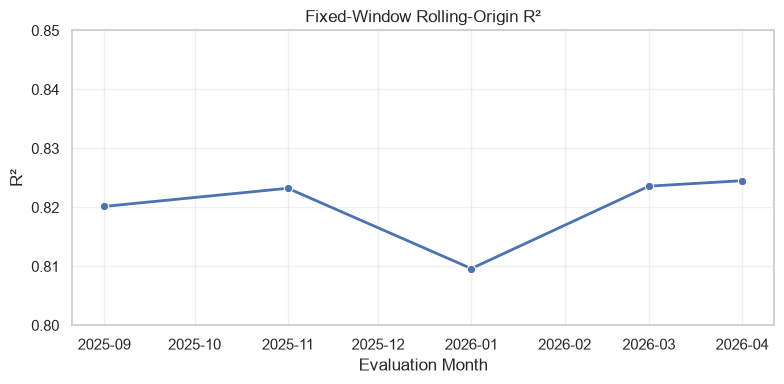

In [65]:
stability_summary = pd.DataFrame([{
    "train_window_months": fixed_train_window_months,
    "n_cutoffs": stability_results["eval_month"].nunique(),
    "mean_r2": stability_results["r2"].mean(),
    "std_r2": stability_results["r2"].std(),
    "min_r2": stability_results["r2"].min(),
    "max_r2": stability_results["r2"].max(),
    "mean_mae": stability_results["mae"].mean(),
    "mean_rmse": stability_results["rmse"].mean(),
    "mean_mape": stability_results["mape"].mean(),
    "mean_mdape": stability_results["mdape"].mean(),
    "std_mdape": stability_results["mdape"].std(),
}])

stability_summary.to_csv(OUTPUT_DIR / "rolling_origin_summary.csv", index=False)
display(stability_summary.round(4))

plot_df = stability_results.copy()
plot_df["eval_month_date"] = pd.to_datetime(plot_df["eval_month"])

fig, ax = plt.subplots(figsize=(8, 4))

sns.lineplot(
    data=plot_df,
    x="eval_month_date",
    y="r2",
    marker="o",
    linewidth=2,
    ax=ax,
)

ax.set_title("Fixed-Window Rolling-Origin R²")
ax.set_xlabel("Evaluation Month")
ax.set_ylabel("R²")
ax.set_ylim(0.80, 0.85)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Final Test Evaluation

Train the fixed-window baseline on `2025-12` through `2026-04`, then evaluate once on `2026-05`.


In [62]:
test_df_raw = load_split_file(TEST_CSV)
final_train_df_raw = load_split_file(FINAL_TRAIN_CSV)
final_train_df, final_test_df, final_bound_info = apply_train_price_bounds(final_train_df_raw, test_df_raw)

final_model = build_baseline_model()
final_model.fit(final_train_df[feature_cols], final_train_df[target])

final_train_predictions = final_model.predict(final_train_df[feature_cols])
final_predictions = final_model.predict(final_test_df[feature_cols])

final_train_metrics = regression_metrics(final_train_df[target], final_train_predictions)
final_metrics = regression_metrics(final_test_df[target], final_predictions)

joblib.dump({
    "model": final_model,
    "feature_cols": feature_cols,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "boolean_cols": boolean_cols,
    "flag_cols": flag_cols,
    "target": target,
    "price_bounds": {
        "lower": final_bound_info["price_lower_bound"],
        "upper": final_bound_info["price_upper_bound"],
    },
    "train_months": final_plan["train_months"],
    "test_month": final_plan["eval_month"],
}, MODEL_PATH)

final_results_df = pd.DataFrame([{
    "model": "LinearRegression",
    "target": target,
    "train_window_months": fixed_train_window_months,
    "final_train_month_start": final_plan["train_month_start"],
    "final_train_month_end": final_plan["train_month_end"],
    "final_train_months": final_plan["train_months"],
    "test_month": final_plan["eval_month"],
    **final_bound_info,
    "train_r2": final_train_metrics["r2"],
    "train_mae": final_train_metrics["mae"],
    "test_r2": final_metrics["r2"],
    "test_mae": final_metrics["mae"],
    "test_rmse": final_metrics["rmse"],
    "test_mape": final_metrics["mape"],
    "test_mdape": final_metrics["mdape"],
    "model_path": str(MODEL_PATH.relative_to(PROJECT_ROOT)),
}])

final_results_df.to_csv(OUTPUT_DIR / "final_test_results.csv", index=False)
display(final_results_df)


,model,target,train_window_months,final_train_month_start,final_train_month_end,final_train_months,test_month,price_lower_bound,price_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,train_r2,train_mae,test_r2,test_mae,test_rmse,test_mape,test_mdape,model_path
0,LinearRegression,ClosePrice,5,2025-12,2026-04,"2025-12, 2026-01, 2026-02, 2026-03, 2026-04",2026-05,185000.0,9250000.0,49667,49177,12024,11919,0.841152,227469.35435,0.83227,247176.786082,413890.359568,23.043397,16.049778,models/linear_regression_baseline_pipeline.joblib


## 7. Prediction Diagnostics

Save row-level predictions and summarize final-test errors by price band and county.


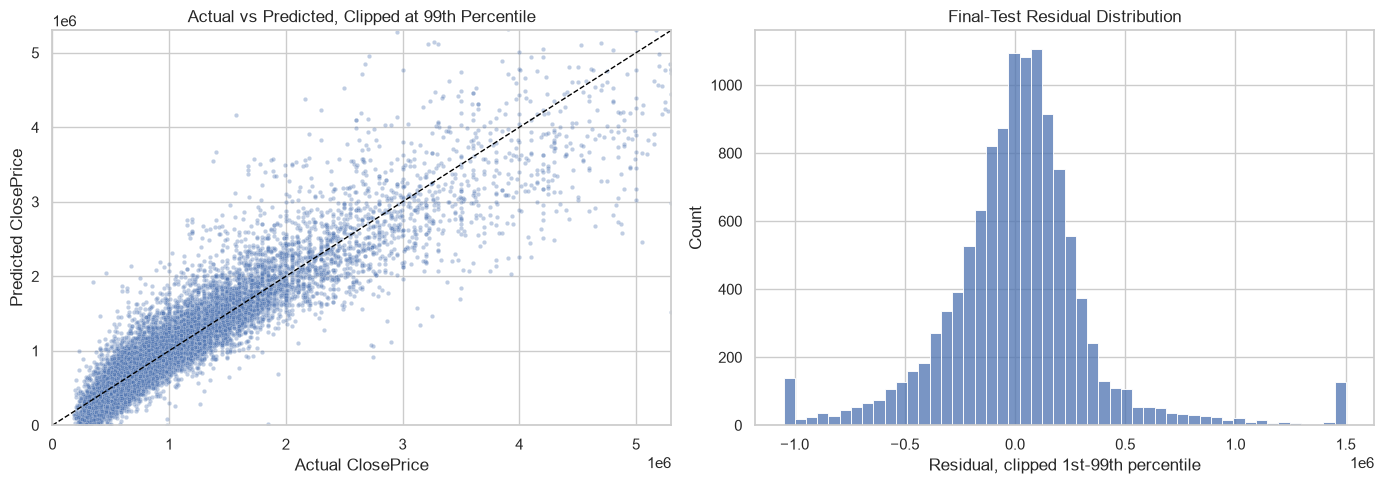

In [63]:
residuals = final_test_df[["ListingKey", "CloseDate", "close_month", "CountyOrParish", target]].copy()
residuals["predicted_ClosePrice"] = final_predictions
residuals["residual"] = residuals[target] - residuals["predicted_ClosePrice"]
residuals["absolute_error"] = residuals["residual"].abs()
residuals["absolute_percentage_error"] = residuals["absolute_error"] / residuals[target] * 100
residuals.to_csv(OUTPUT_DIR / "test_predictions_linear_regression.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
max_price = np.nanpercentile(final_test_df[target], 99)
sns.scatterplot(x=final_test_df[target], y=final_predictions, s=10, alpha=0.35, ax=axes[0])
axes[0].plot([0, max_price], [0, max_price], color="black", linestyle="--", linewidth=1)
axes[0].set_xlim(0, max_price)
axes[0].set_ylim(0, max_price)
axes[0].set_xlabel("Actual ClosePrice")
axes[0].set_ylabel("Predicted ClosePrice")
axes[0].set_title("Actual vs Predicted, Clipped at 99th Percentile")

sns.histplot(
    residuals["residual"].clip(residuals["residual"].quantile(0.01), residuals["residual"].quantile(0.99)),
    bins=50,
    ax=axes[1],
)
axes[1].set_xlabel("Residual, clipped 1st-99th percentile")
axes[1].set_title("Final-Test Residual Distribution")
plt.tight_layout()
plt.show()


## 8. Baseline Summary

This notebook does not choose among multiple X windows. It keeps the existing fixed 5-month training window and uses five historical cutoffs to check stability. The final Linear Regression baseline is trained on `2025-12` through `2026-04` and evaluated once on `2026-05`.


In [64]:
baseline_summary = pd.concat([
    stability_summary.add_prefix("stability_"),
    final_results_df.add_prefix("final_"),
], axis=1)

display(baseline_summary.T.rename(columns={0: "value"}))
print(f"Fixed training window: {fixed_train_window_months} months")
print(f"Historical mean R²: {stability_summary['mean_r2'].iloc[0]:.4f}")
print(f"Historical R² std: {stability_summary['std_r2'].iloc[0]:.4f}")
print(f"Final train R²: {final_train_metrics['r2']:.4f}")
print(f"Final train MAE: ${final_train_metrics['mae']:,.0f}")
print(f"Final test R²: {final_metrics['r2']:.4f}")
print(f"Final test MAE: ${final_metrics['mae']:,.0f}")
print(f"Final test MdAPE: {final_metrics['mdape']:.2f}%")
print(f"Saved outputs to: {OUTPUT_DIR}")
print(f"Saved fitted pipeline to: {MODEL_PATH}")


,value
stability_train_window_months,5
stability_n_cutoffs,5
stability_mean_r2,0.820224
stability_std_r2,0.006154
stability_min_r2,0.809613
stability_max_r2,0.82452
stability_mean_mae,236728.789796
stability_mean_rmse,409824.319419
stability_mean_mape,22.950587
stability_mean_mdape,16.05433


Fixed training window: 5 months
Historical mean R²: 0.8202
Historical R² std: 0.0062
Final train R²: 0.8412
Final train MAE: $227,469
Final test R²: 0.8323
Final test MAE: $247,177
Final test MdAPE: 16.05%
Saved outputs to: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week4_baseline
Saved fitted pipeline to: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/models/linear_regression_baseline_pipeline.joblib
